# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1021,11,45,"(0.95, 1.3)","(-0.012, 0.579, 0.078, -0.647)",1,1.0,"(-0.001, 0.773, 0.065, -0.916)",0.0,1.0,"(0.015, 0.577, 0.047, -0.6)"
1960,22,83,"(0.79, 1.8)","(0.087, 0.341, -0.118, -0.517)",0,1.0,"(0.094, 0.152, -0.129, -0.377)",0.0,1.0,"(0.097, -0.036, -0.136, -0.239)"
47,17,2,"(0.57, 1.2)","(0.16, 0.557, -0.172, -0.751)",0,1.0,"(0.171, 0.369, -0.187, -0.605)",0.0,1.0,"(0.178, 0.18, -0.199, -0.463)"
1126,34,49,"(0.23, 1.3)","(-0.085, -0.363, 0.028, 0.212)",1,1.0,"(-0.092, -0.176, 0.032, 0.091)",1.0,1.0,"(-0.096, 0.011, 0.034, -0.029)"
2282,14,99,"(0.43, 0.6)","(-0.002, 0.001, 0.032, 0.162)",1,1.0,"(-0.002, 0.197, 0.035, -0.148)",1.0,1.0,"(0.002, 0.393, 0.032, -0.457)"
...,...,...,...,...,...,...,...,...,...,...
1902,20,81,"(0.39, 0.2)","(-0.003, -0.039, 0.042, 0.24)",1,1.0,"(-0.004, 0.183, 0.046, -0.645)",1.0,1.0,"(-0.0, 0.405, 0.033, -1.526)"
1803,31,74,"(0.22, 0.7)","(0.236, 0.204, -0.195, -0.435)",0,1.0,"(0.24, 0.014, -0.204, -0.259)",0.0,1.0,"(0.241, -0.175, -0.209, -0.086)"
1469,44,63,"(0.1, 1.6)","(0.192, 0.056, -0.132, -0.14)",1,1.0,"(0.193, 0.242, -0.135, -0.243)",0.0,1.0,"(0.198, 0.057, -0.139, -0.166)"
986,30,43,"(0.43, 1.3)","(-0.248, -1.177, 0.126, 0.921)",0,1.0,"(-0.272, -1.366, 0.145, 1.087)",1.0,1.0,"(-0.299, -1.178, 0.166, 0.964)"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.24293336272239685, 0.68392014503479, 0.1026...",2.150924,1.566361
1,1,"[0.23888415098190308, 0.6761690378189087, 0.10...",2.128207,1.565061
2,2,"[0.234870046377182, 0.668491780757904, 0.09782...",2.105695,1.563813
3,3,"[0.23089247941970825, 0.6609011292457581, 0.09...",2.083388,1.562615
4,4,"[0.2269536405801773, 0.6534171104431152, 0.093...",2.061282,1.561468


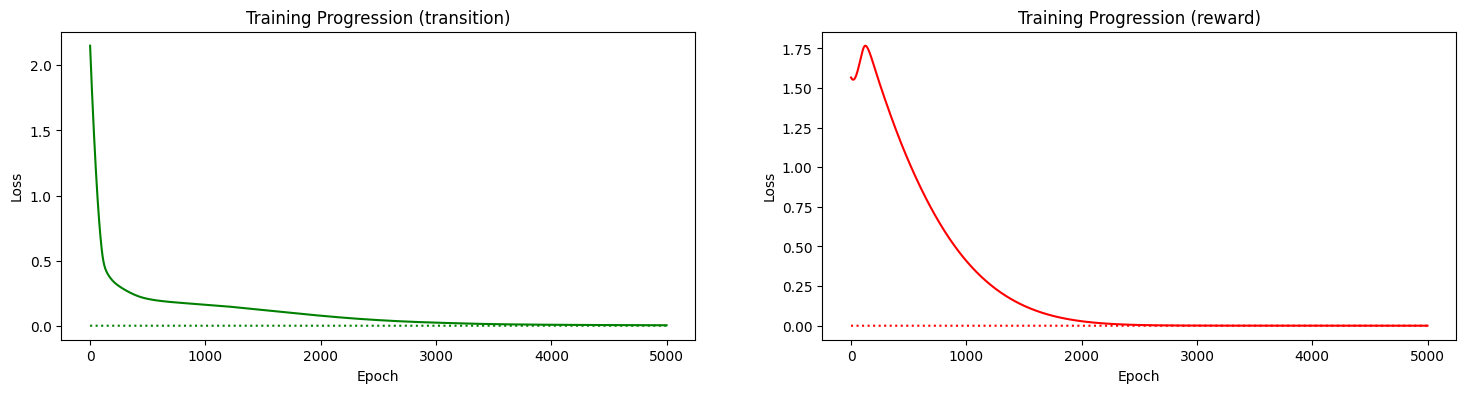

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

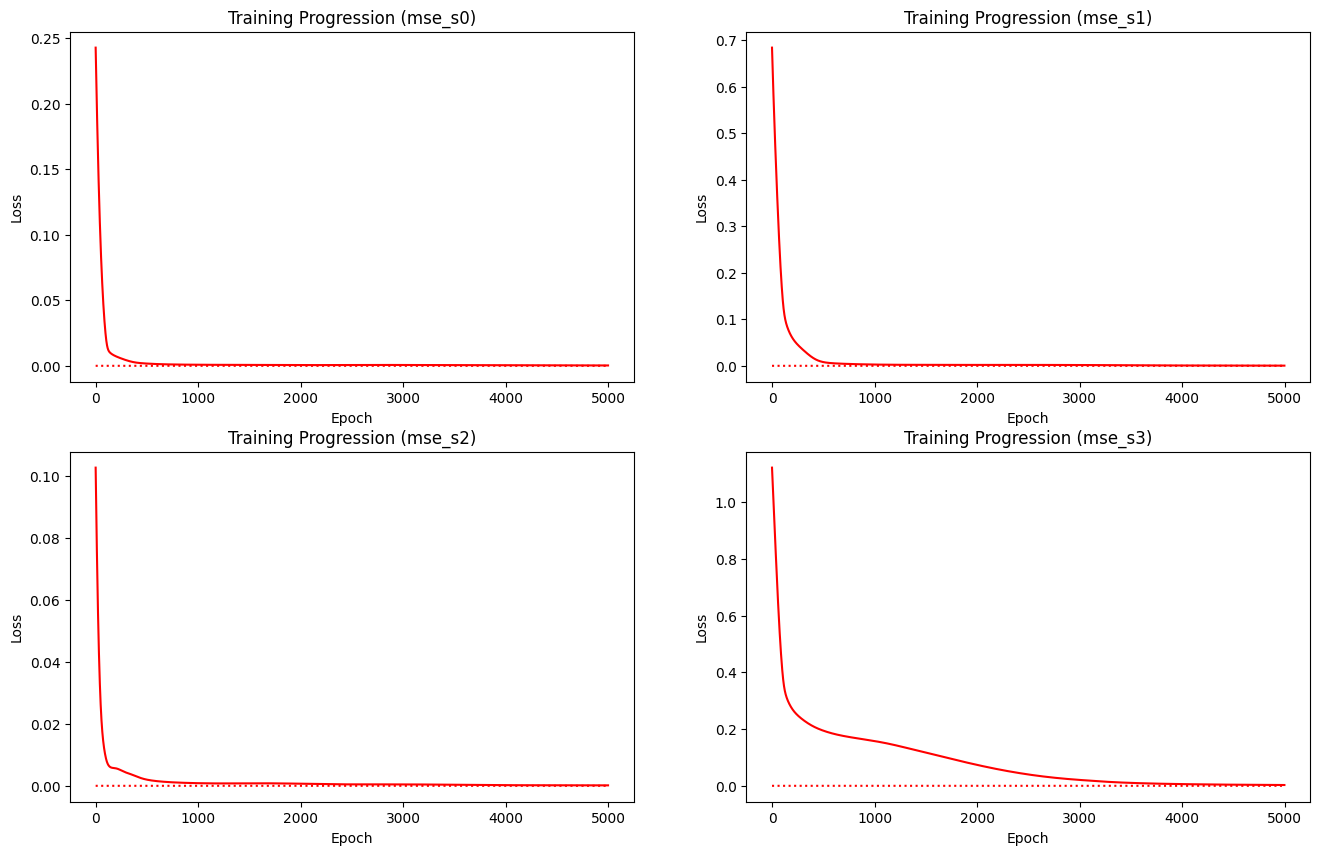

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s3,estimated_s0,estimated_s1,estimated_s2,estimated_s3,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.018,-0.000,-0.043,-0.014,-0.020,0.010,0.001,0.002,0.002,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.218,-0.007,0.141,-0.016,-0.204,0.004,0.008,0.000,0.014,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.418,-0.001,0.338,-0.021,-0.403,0.007,0.002,0.000,0.015,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.619,0.009,0.533,-0.032,-0.604,0.010,0.002,0.003,0.015,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.822,0.022,0.727,-0.048,-0.809,0.013,0.005,0.007,0.013,0.0


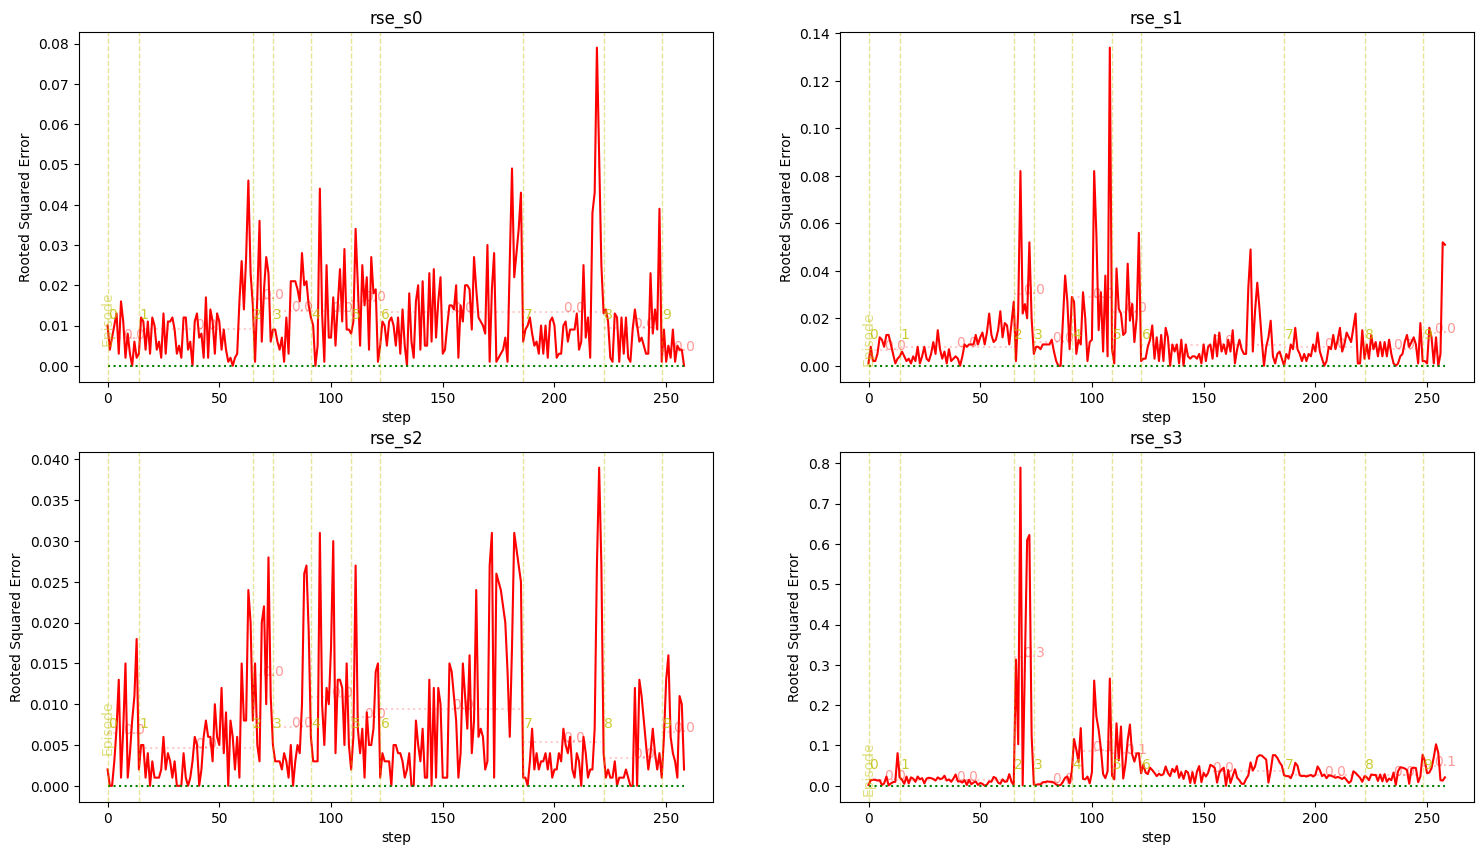

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

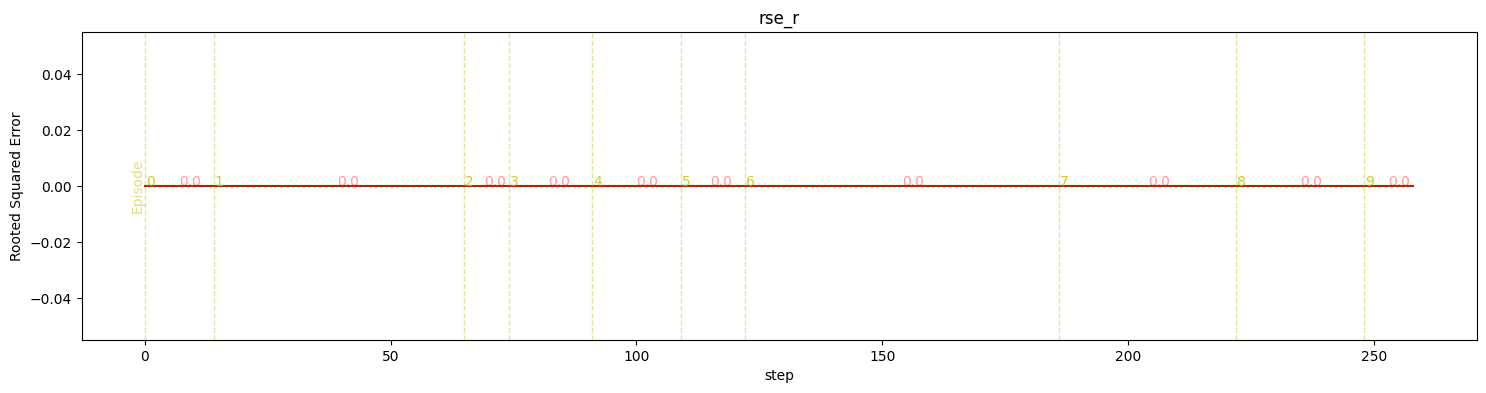

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

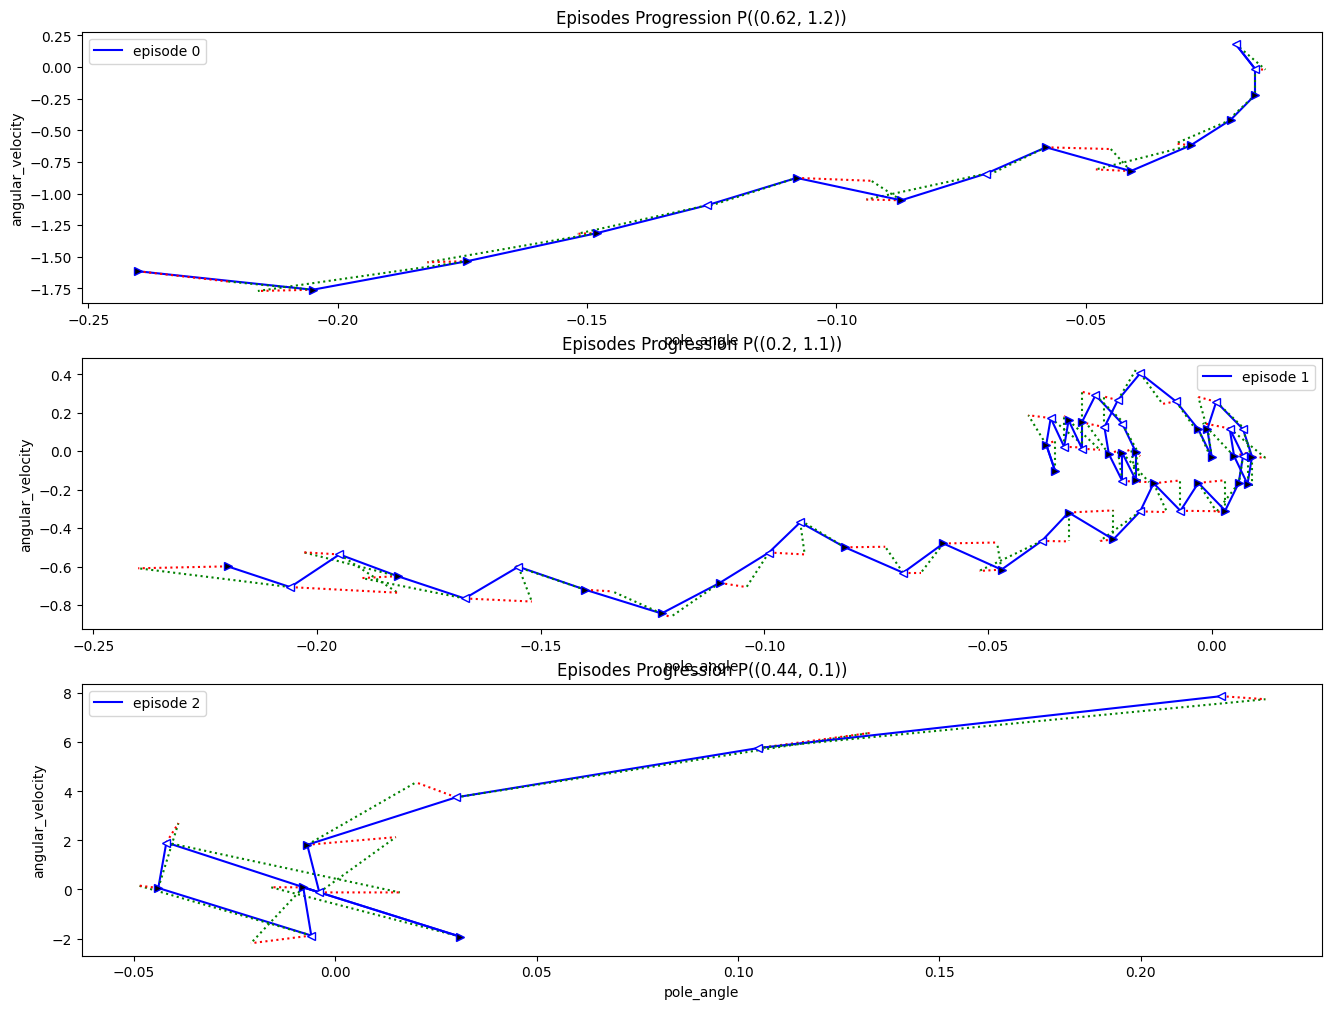

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()